# Параметрическая серия

В серии изменяются число философов и интенсивность захвата второй вилки.
Для каждой точки выполняются независимые повторы обеих структур сети.

In [1]:
using DrWatson
@quickactivate "PetriDiningLab"

ENV["GKSwstype"] = "100"
using CairoMakie
using CSV
using DataFrames
using Random
using Statistics

include(srcdir("DiningPhilosophers.jl"))
using .DiningPhilosophers

## Сетка параметров

In [2]:
const COUNTS = (3, 5, 7)
const SECOND_FORK_RATES = (0.4, 0.8, 1.2)
const REPLICATIONS = 12
const HORIZON = 50.0

rows = NamedTuple[]
for count in COUNTS, right_rate in SECOND_FORK_RATES,
    replication in 1:REPLICATIONS
    rates = vcat(fill(2.4, count), fill(right_rate, count), fill(1.1, count))
    for (variant, builder, offset) in
        (("Классическая", build_classical_network, 0),
         ("С арбитром", build_arbiter_network, 50_000))
        net, initial = builder(count)
        seed = 10_000count + 1_000round(Int, 10right_rate) +
               replication + offset
        result = simulate_stochastic(net, initial, HORIZON;
            rates=rates, rng=MersenneTwister(seed))
        meals = sum(result.meal_counts)
        fairness = meals == 0 ? 0.0 :
            meals^2 / (count * sum(abs2, result.meal_counts))
        push!(rows, (philosophers=count, right_rate=right_rate,
                     replication=replication, variant=variant,
                     deadlock=result.deadlock, events=nrow(result.events),
                     meals=meals, throughput=meals / HORIZON,
                     fairness=fairness,
                     observed_until=last(result.trajectory.time)))
    end
end

runs = DataFrame(rows)
summary = combine(groupby(runs, [:philosophers, :right_rate, :variant]),
    :deadlock => mean => :deadlock_probability,
    :throughput => mean => :mean_throughput,
    :throughput => std => :sd_throughput,
    :fairness => mean => :mean_fairness,
    :events => mean => :mean_events)

mkpath(datadir("dining-parameter-series"))
CSV.write(datadir("dining-parameter-series", "replications.csv"), runs)
CSV.write(datadir("dining-parameter-series", "summary.csv"), summary)

println("=== Параметрическая серия сетей Петри ===")
println("Траекторий: $(nrow(runs))")
println("Агрегированных комбинаций: $(nrow(summary))")
show(summary; allrows=true, allcols=true)
println()

=== Параметрическая серия сетей Петри ===
Траекторий: 216
Агрегированных комбинаций: 18
18×8 DataFrame
 Row │ philosophers  right_rate  variant       deadlock_probability  mean_throughput  sd_throughput  mean_fairness  mean_events
     │ Int64         Float64     String        Float64               Float64          Float64        Float64        Float64
─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │            3         0.4  Классическая                   1.0       0.00666667     0.0130268       0.111111        4.0
   2 │            3         0.4  С арбитром                     0.0       0.301667       0.0646435       0.930946       47.5
   3 │            3         0.8  Классическая                   1.0       0.00333333     0.00778499      0.0555556       3.5
   4 │            3         0.8  С арбитром                     0.0       0.465          0.0591608       0.93985        72.0
   5 │          

## Вероятность deadlock и производительность

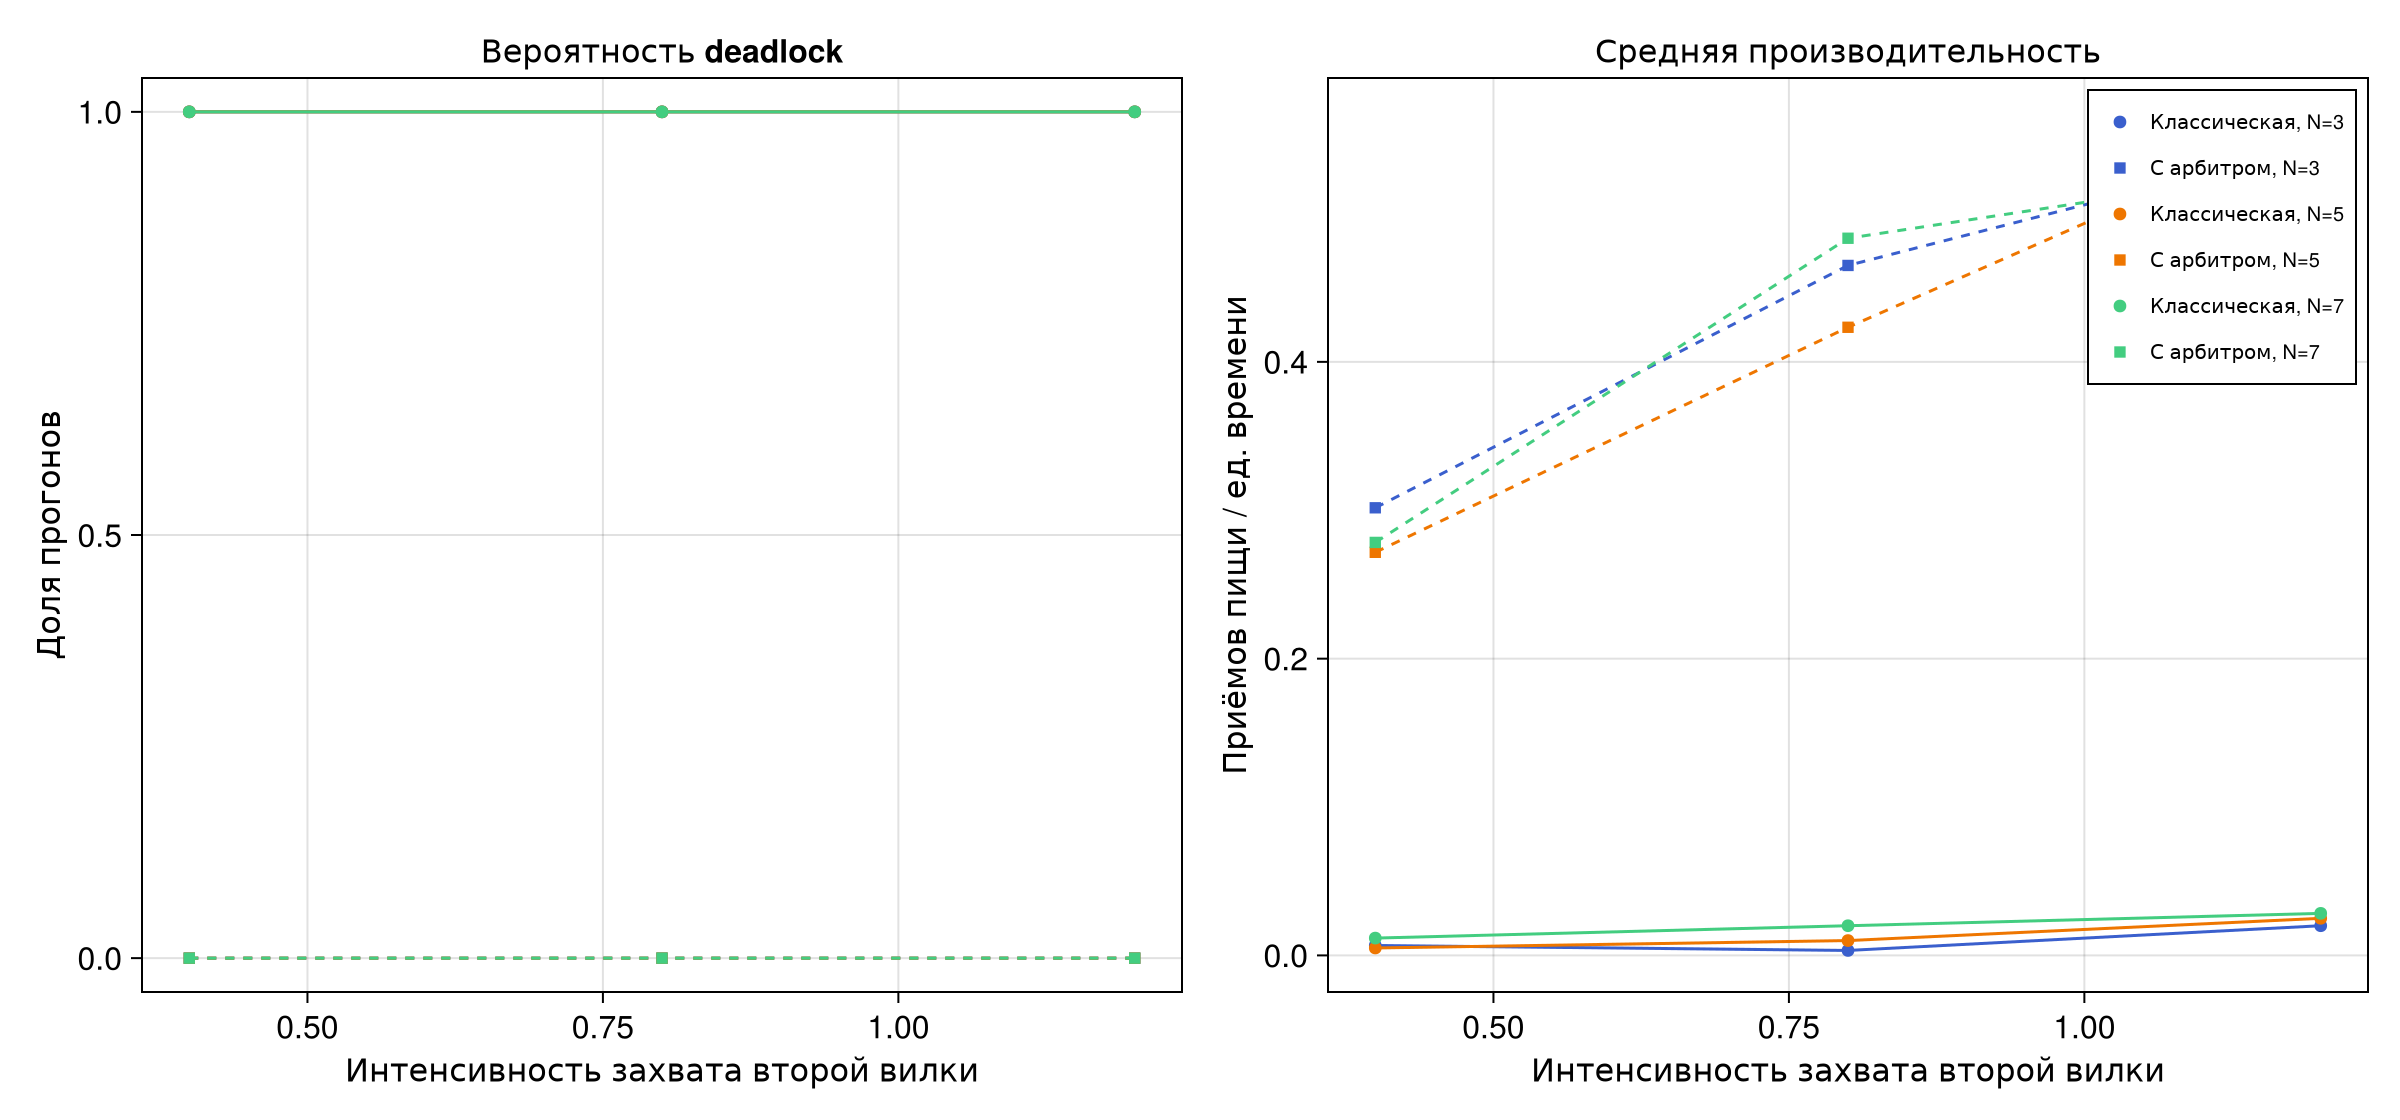

In [3]:
figure = Figure(size=(1200, 560), fontsize=16)
deadlock_axis = Axis(figure[1, 1], title="Вероятность deadlock",
                     xlabel="Интенсивность захвата второй вилки",
                     ylabel="Доля прогонов", limits=(nothing, (-0.04, 1.04)))
throughput_axis = Axis(figure[1, 2], title="Средняя производительность",
                       xlabel="Интенсивность захвата второй вилки",
                       ylabel="Приёмов пищи / ед. времени")

palette = Dict(3 => :royalblue3, 5 => :darkorange2, 7 => :seagreen3)
markers = Dict("Классическая" => :circle, "С арбитром" => :rect)
for count in COUNTS, variant in ("Классическая", "С арбитром")
    subset = filter(row -> row.philosophers == count && row.variant == variant,
                    summary)
    sort!(subset, :right_rate)
    label = "$(variant), N=$(count)"
    line_style = variant == "Классическая" ? :solid : :dash
    lines!(deadlock_axis, subset.right_rate, subset.deadlock_probability;
           color=palette[count], linestyle=line_style)
    scatter!(deadlock_axis, subset.right_rate, subset.deadlock_probability;
             color=palette[count], marker=markers[variant], label=label)
    lines!(throughput_axis, subset.right_rate, subset.mean_throughput;
           color=palette[count], linestyle=line_style)
    scatter!(throughput_axis, subset.right_rate, subset.mean_throughput;
             color=palette[count], marker=markers[variant], label=label)
end
axislegend(throughput_axis; position=:rt, labelsize=10)
save(plotsdir("parameter_series.png"), figure, px_per_unit=1.5)
figure

Повышение скорости получения второй вилки сокращает окно циклического
ожидания. Арбитр устраняет глобальную блокировку во всех точках серии.